In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# ─── 1. Data load karo ───────────────────────────────
df = pd.read_csv('../data/creditcard.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Normal: 284315 (99.83%)
Fraud:  492 (0.17%)


C:\Users\ratho\AppData\Local\Temp\ipykernel_16712\2488676966.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#00d4ff', '#ff4d6d'])


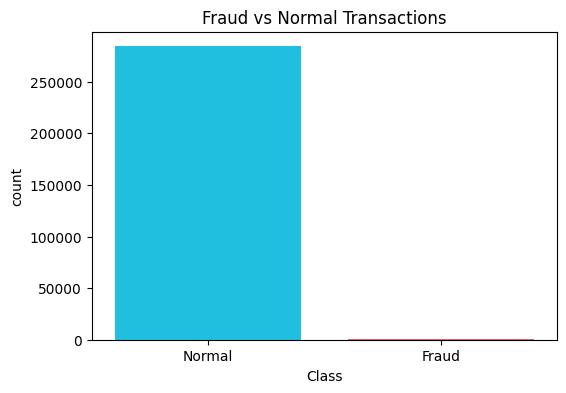

In [5]:
# ─── 2. Fraud distribution dekho ─────────────────────
fraud_count = df['Class'].value_counts()
print(f"\nNormal: {fraud_count[0]} ({fraud_count[0]/len(df)*100:.2f}%)")
print(f"Fraud:  {fraud_count[1]} ({fraud_count[1]/len(df)*100:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#00d4ff', '#ff4d6d'])
plt.title('Fraud vs Normal Transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.savefig('../outputs/class_distribution.png')
plt.show()

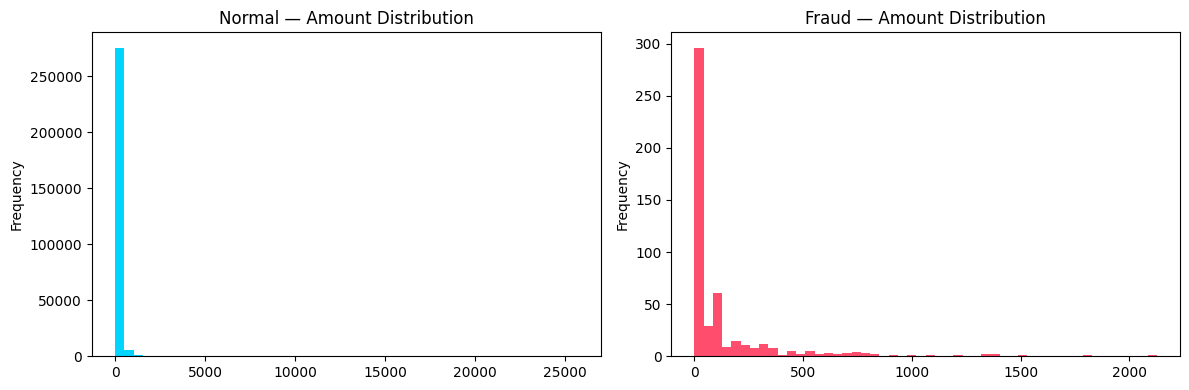

In [6]:
# ─── 3. Transaction Amount distribution ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class']==0]['Amount'].plot(
    kind='hist', bins=50, ax=axes[0],
    title='Normal — Amount Distribution', color='#00d4ff'
)
df[df['Class']==1]['Amount'].plot(
    kind='hist', bins=50, ax=axes[1],
    title='Fraud — Amount Distribution', color='#ff4d6d'
)
plt.tight_layout()
plt.savefig('../outputs/amount_distribution.png')
plt.show()

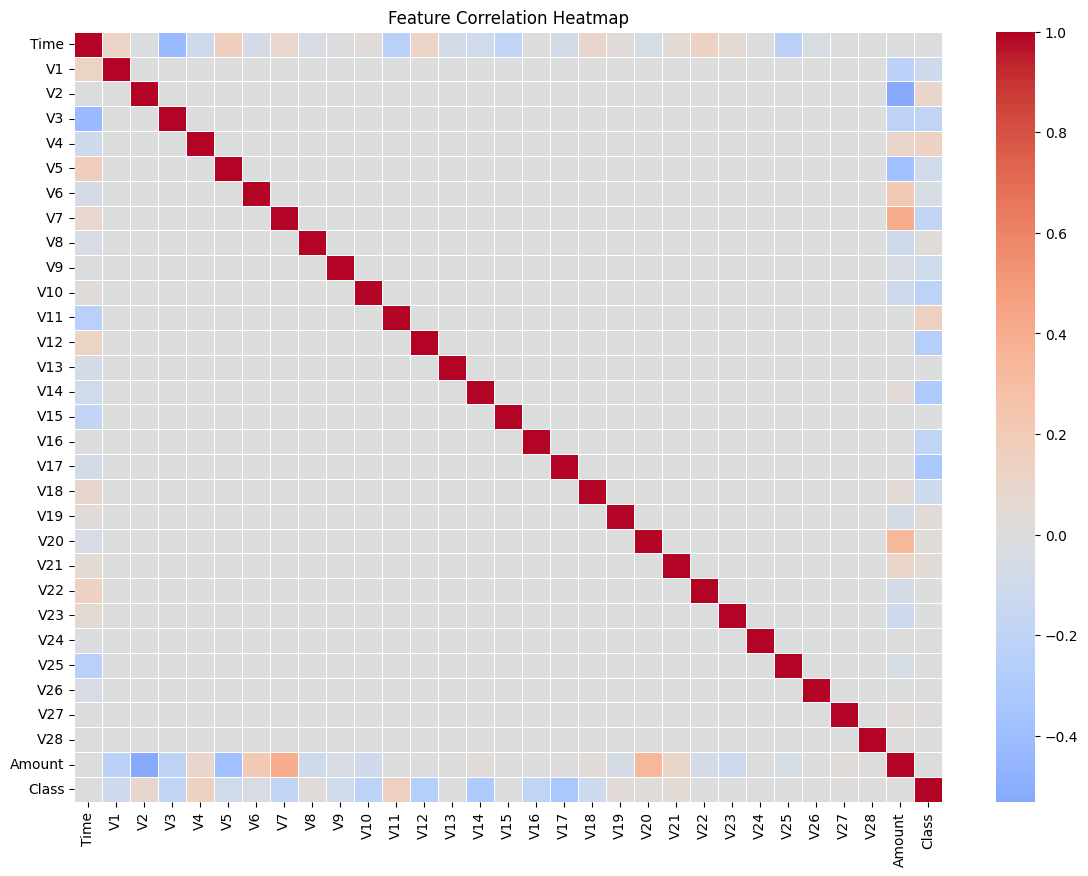

In [7]:
# ─── 4. Correlation heatmap ───────────────────────────
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, 
            linewidths=0.5, fmt='.1f')
plt.title('Feature Correlation Heatmap')
plt.savefig('../outputs/correlation.png')
plt.show()

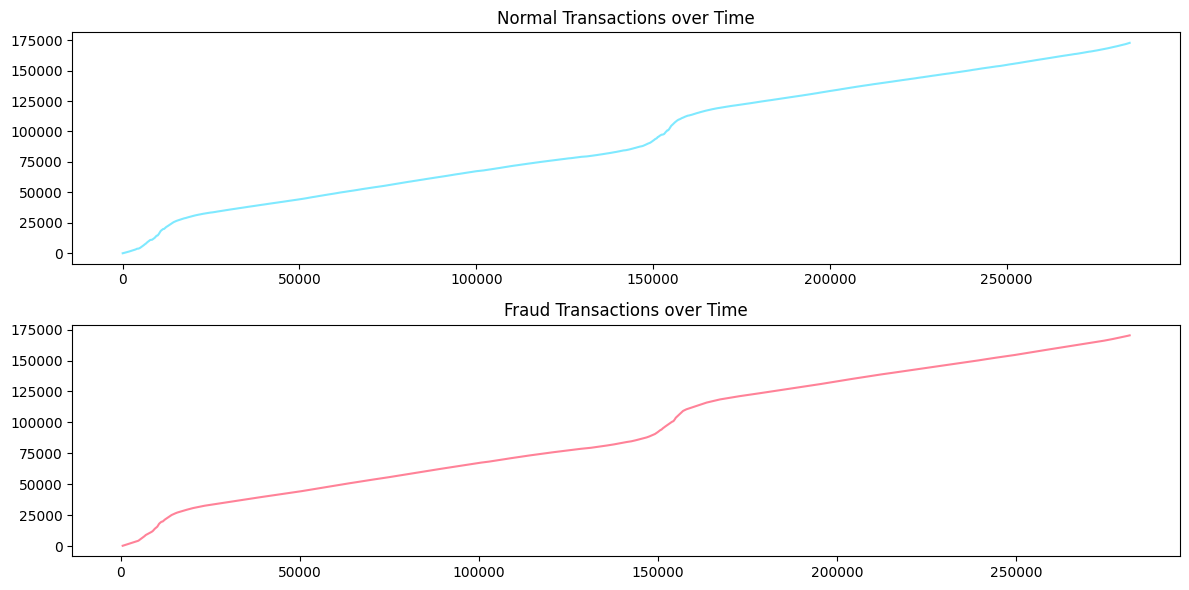

In [8]:
# ─── 5. Fraud transactions time pe kab aate hain ─────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
df[df['Class']==0]['Time'].plot(
    ax=axes[0], title='Normal Transactions over Time', 
    color='#00d4ff', alpha=0.5
)
df[df['Class']==1]['Time'].plot(
    ax=axes[1], title='Fraud Transactions over Time', 
    color='#ff4d6d', alpha=0.7
)
plt.tight_layout()
plt.savefig('../outputs/time_distribution.png')
plt.show()